# Basic evaluator: real vs synthetic, and diversity across seeds

Layer 5-6 built a generator. This notebook builds the first numeric answer
to "does its output actually resemble a real image" - intensity
histogram, edge/gradient strength, frequency-domain texture (PSD), and
whether different seeds actually produce different outputs (diversity) or
silently collapse to the same result.


## 1. Generate: one real image, three same-source synthetic seeds

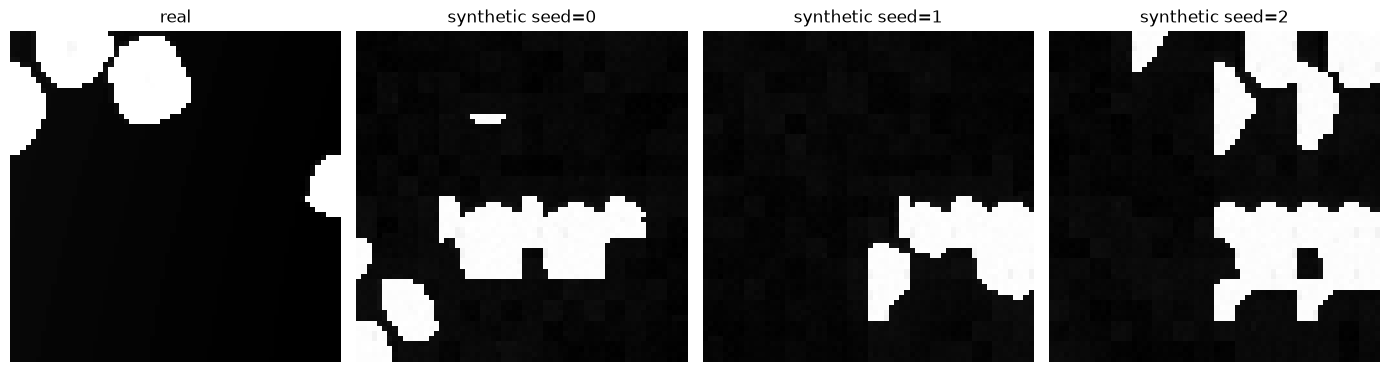

In [1]:
import sys, os
sys.path.append(os.path.join("..", "..", "src"))
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

from data.pyramid import build_pyramid
from models.sampler import sample_coarse_to_fine
from evaluation.metrics import (
    intensity_histogram, gradient_magnitude_histogram,
    power_spectral_density, autocorrelation, diversity_across_seeds,
)

NIST_DIR = os.path.join("..", "..", "..", "AMAT", "nist_detection_limits_sem")
clean_path = os.path.join(NIST_DIR, "mask_sets", "masks", "set1_cex_noise_000_contrast_100.tiff")
real = np.array(Image.open(clean_path)).astype(np.float64)[:64, :64]
pyramid = build_pyramid(real, num_scales=4, scale_factor=0.5)

PATCH_SIZE, STRIDE, NUM_STEPS = 4, 4, 15  # stride=4: Day 18's accepted fast default
synthetic = [sample_coarse_to_fine(pyramid, PATCH_SIZE, STRIDE, NUM_STEPS, seed=s)[0] for s in [0, 1, 2]]

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
axes[0].imshow(real, cmap="gray"); axes[0].set_title("real")
for i, img in enumerate(synthetic):
    axes[i+1].imshow(img, cmap="gray"); axes[i+1].set_title(f"synthetic seed={i}")
for ax in axes: ax.axis("off")
plt.tight_layout(); plt.show()


## 2. Intensity histogram: real vs synthetic

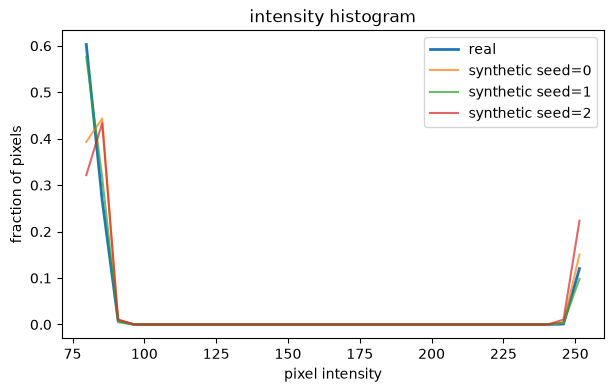

In [2]:
shared_range = (min(real.min(), *[s.min() for s in synthetic]), max(real.max(), *[s.max() for s in synthetic]))
real_hist, edges = intensity_histogram(real, bins=32, value_range=shared_range)

plt.figure(figsize=(7, 4))
plt.plot(edges[:-1], real_hist, label="real", linewidth=2)
for i, img in enumerate(synthetic):
    hist, _ = intensity_histogram(img, bins=32, value_range=shared_range)
    plt.plot(edges[:-1], hist, label=f"synthetic seed={i}", alpha=0.7)
plt.xlabel("pixel intensity"); plt.ylabel("fraction of pixels"); plt.legend(); plt.title("intensity histogram")
plt.show()


## 3. Gradient magnitude (edge strength) histogram: real vs synthetic

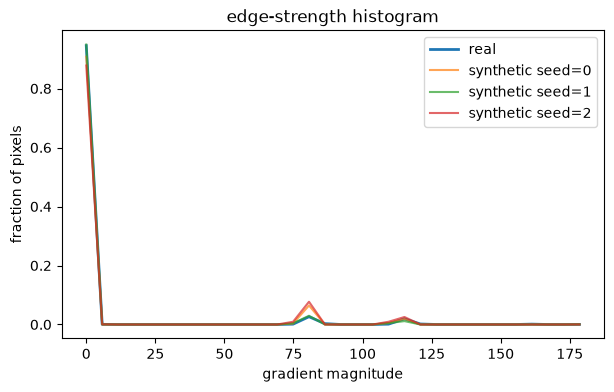

In [3]:
real_grad, gedges = gradient_magnitude_histogram(real, bins=32)

plt.figure(figsize=(7, 4))
plt.plot(gedges[:-1], real_grad, label="real", linewidth=2)
for i, img in enumerate(synthetic):
    grad, _ = gradient_magnitude_histogram(img, bins=32)
    plt.plot(gedges[:-1], grad, label=f"synthetic seed={i}", alpha=0.7)
plt.xlabel("gradient magnitude"); plt.ylabel("fraction of pixels"); plt.legend(); plt.title("edge-strength histogram")
plt.show()


## 4. Power spectral density: is texture concentrated at the right frequencies?

A radially-averaged spectrum: x-axis is spatial frequency (0 = overall
brightness, already excluded; higher = finer texture detail), y-axis is
how much of the image's energy lives at that frequency.

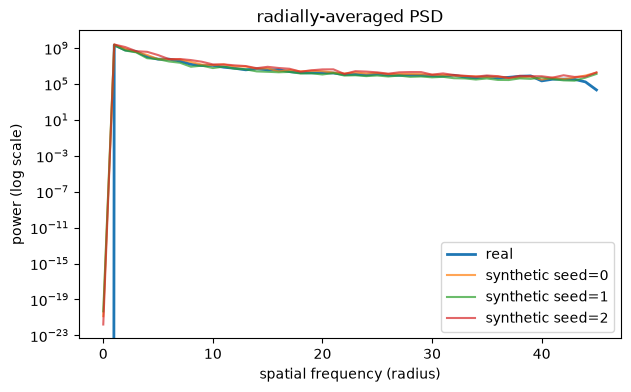

In [4]:
plt.figure(figsize=(7, 4))
plt.semilogy(power_spectral_density(real), label="real", linewidth=2)
for i, img in enumerate(synthetic):
    plt.semilogy(power_spectral_density(img), label=f"synthetic seed={i}", alpha=0.7)
plt.xlabel("spatial frequency (radius)"); plt.ylabel("power (log scale)"); plt.legend(); plt.title("radially-averaged PSD")
plt.show()


## 5. Diversity across seeds: are the three synthetic images actually different?

In [5]:
div = diversity_across_seeds(synthetic)
print(f"mean pairwise pixel difference across seeds: {div:.2f}")
print(f"for reference, real image's own std: {real.std():.2f}")


mean pairwise pixel difference across seeds: 36.07
for reference, real image's own std: 55.64


## Findings

What to read off each plot, plus this run's actual numbers:

- **Intensity histogram overlap** close to the real curve means the
  generator reproduces overall brightness/contrast distribution, not just
  a visually-similar average brightness.
- **Gradient histogram** heavier at low magnitudes than the real curve
  would mean the synthetic output is smoother/blurrier than real texture -
  a quantitative version of the "does it look sharp enough" question.
- **PSD** curves that drop off faster than the real curve at high
  frequency indicate missing fine detail; a synthetic curve sitting above
  the real one at high frequency would indicate synthetic noise/artifacts
  not present in the real texture.
- **Diversity across seeds: mean pairwise pixel difference = 36.07**,
  compared to the real image's own std of 55.64. This is neither ~0 (which
  would mean mode collapse - all seeds produce nearly the same image) nor
  far larger than the real image's own variation (which would mean the
  seeds are closer to independent noise than to genuine same-source
  variations). 36.07 sits in between, at roughly two-thirds of the real
  image's own std - consistent with "different plausible generations of
  the same source", not a collapse warning, though this single number
  should be re-checked once Layer 7's fuller evaluation (Day 20 onward)
  gives more context for what a good/bad diversity value actually is here.
